In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('/content/archive (3).zip')

In [3]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [4]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [6]:
## target column
df['fraudulent'].value_counts()

,count
fraudulent,
0,17014
1,866


In [9]:
df.dtypes

,0
job_id,int64
title,object
location,object
department,object
salary_range,object
company_profile,object
description,object
requirements,object
benefits,object
telecommuting,int64


In [17]:
df.isnull().sum().sort_values(ascending=False)

,0
required_education,8105
benefits,7212
required_experience,7050
function,6455
industry,4903
employment_type,3471
company_profile,3308
requirements,2696
location,346
description,1


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [14]:
df.drop(['salary_range' , 'job_id' , 'department' ] , axis=1 , inplace=True)

In [16]:
df['employment_type'].value_counts()

,count
employment_type,
Full-time,11620
Contract,1524
Part-time,797
Temporary,241
Other,227


In [19]:
df.head(3)

,title,location,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,Marketing Intern,"US, NY, New York","We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland","90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


In [24]:
text_cols = [
    'title' , 'location' , 'company_profile' , 'description' , 'requirements' , 'benefits' , 'employment_type' , 'required_experience' , 'required_education' , 'industry' , 'function'
]

for col in text_cols:
    df[col] = df[col].fillna("")

In [26]:
df[text_cols].isnull().sum()

,0
title,0
location,0
company_profile,0
description,0
requirements,0
benefits,0
employment_type,0
required_experience,0
required_education,0
industry,0


In [28]:
df["text"] = df[text_cols].apply(lambda x: " ".join(x), axis=1)

In [32]:
df.head()

,title,location,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,text
0,Marketing Intern,"US, NY, New York","We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,,0,1,0,Other,Internship,,,Marketing,0,"Marketing Intern US, NY, New York We're Food52..."
1,Customer Service - Cloud Video Production,"NZ, , Auckland","90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,,Marketing and Advertising,Customer Service,0,"Customer Service - Cloud Video Production NZ, ..."
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,,0,1,0,,,,,,0,"Commissioning Machinery Assistant (CMA) US, IA..."
3,Account Executive - Washington DC,"US, DC, Washington",Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,"Account Executive - Washington DC US, DC, Wash..."
4,Bill Review Manager,"US, FL, Fort Worth",SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,"Bill Review Manager US, FL, Fort Worth SpotSou..."


In [37]:
df['text_length'] = df['text'].apply(len)
df['text_length'].describe().T

,text_length
count,17880.000000
mean,2738.476566
std,1470.407345
min,32.000000
25%,1661.000000
50%,2600.000000
75%,3548.000000
max,14994.000000


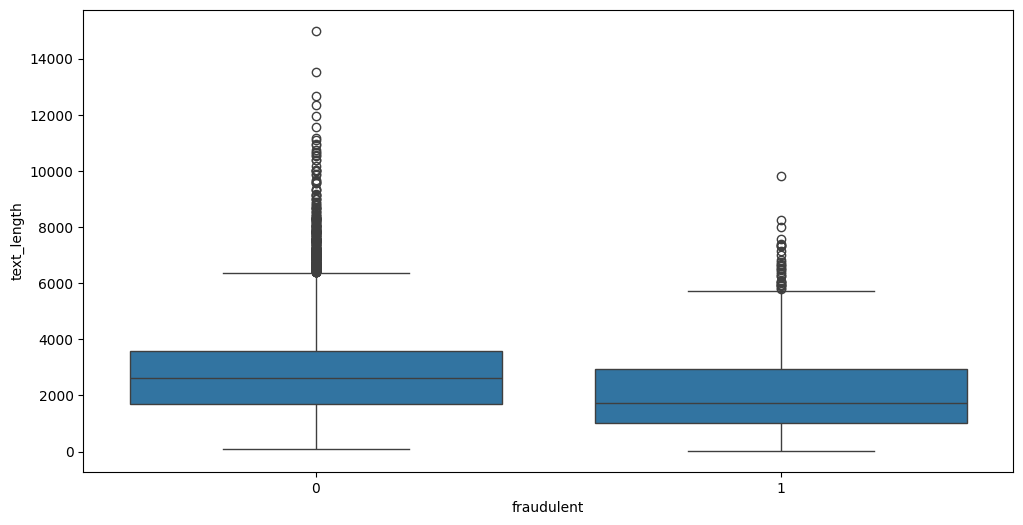

In [35]:
plt.figure(figsize=(12,6))
sns.boxplot(x='fraudulent' , y = 'text_length' , data=df)
plt.show()

In [41]:
from collections import Counter

words = " ".join(df["text"]).split()

Counter(words).most_common(40)

[('and', 361464),
 ('to', 202836),
 ('the', 183909),
 ('of', 152771),
 ('a', 139596),
 ('in', 122774),
 ('with', 89156),
 ('for', 81539),
 ('is', 63550),
 ('our', 53853),
 ('are', 44310),
 ('be', 37274),
 ('on', 36953),
 ('you', 36213),
 ('as', 35896),
 ('or', 34593),
 ('that', 33213),
 ('will', 32743),
 ('work', 30439),
 ('an', 30381),
 ('We', 30201),
 ('we', 27952),
 ('have', 27225),
 ('experience', 25178),
 ('team', 24169),
 ('your', 21972),
 ('all', 19568),
 ('at', 18256),
 ('from', 17651),
 ('by', 17583),
 ('their', 16721),
 ('business', 15266),
 ('&amp;', 15170),
 ('The', 15144),
 ('new', 14746),
 ('-', 14020),
 ('company', 13698),
 ('working', 13688),
 ('customer', 13424),
 ('looking', 11898)]

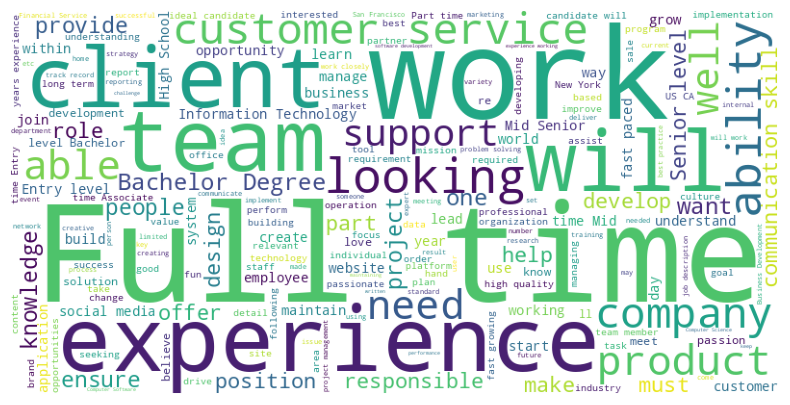

In [43]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["text"])

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

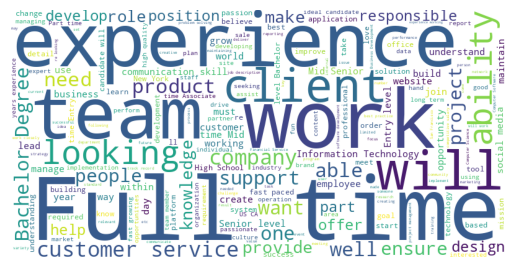

In [46]:
real_text = " ".join(df[df["fraudulent"]==0]["text"])

wordcloud = WordCloud(width=800,height=400,background_color="white").generate(real_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

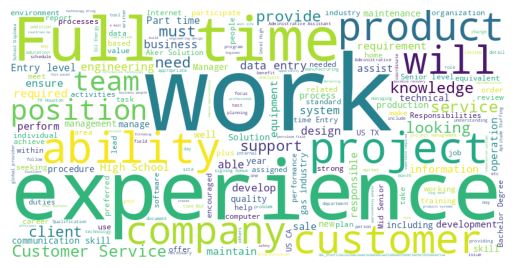

In [47]:
fake_text = " ".join(df[df["fraudulent"]==1]["text"])

wordcloud = WordCloud(width=800,height=400,background_color="white").generate(fake_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

<Axes: xlabel='text_length', ylabel='Count'>

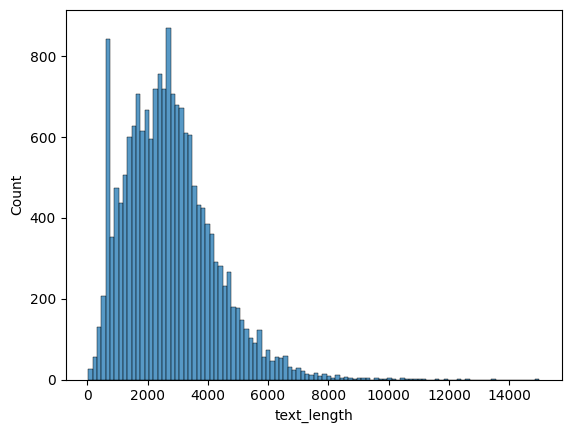

In [48]:
sns.histplot(df["text_length"])

## Key Observations from EDA

- The dataset contains 17,880 job postings.
- The target variable (fraudulent) is highly imbalanced.
- Several columns contain missing values such as salary_range and department.
- Text features from multiple columns were merged into a single text field.
- The distribution of text length is right-skewed, indicating that most job descriptions are medium length while a few are extremely long.